In [48]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


엑셀 파일을 업로드하세요.


Saving data.xlsx to data (36).xlsx


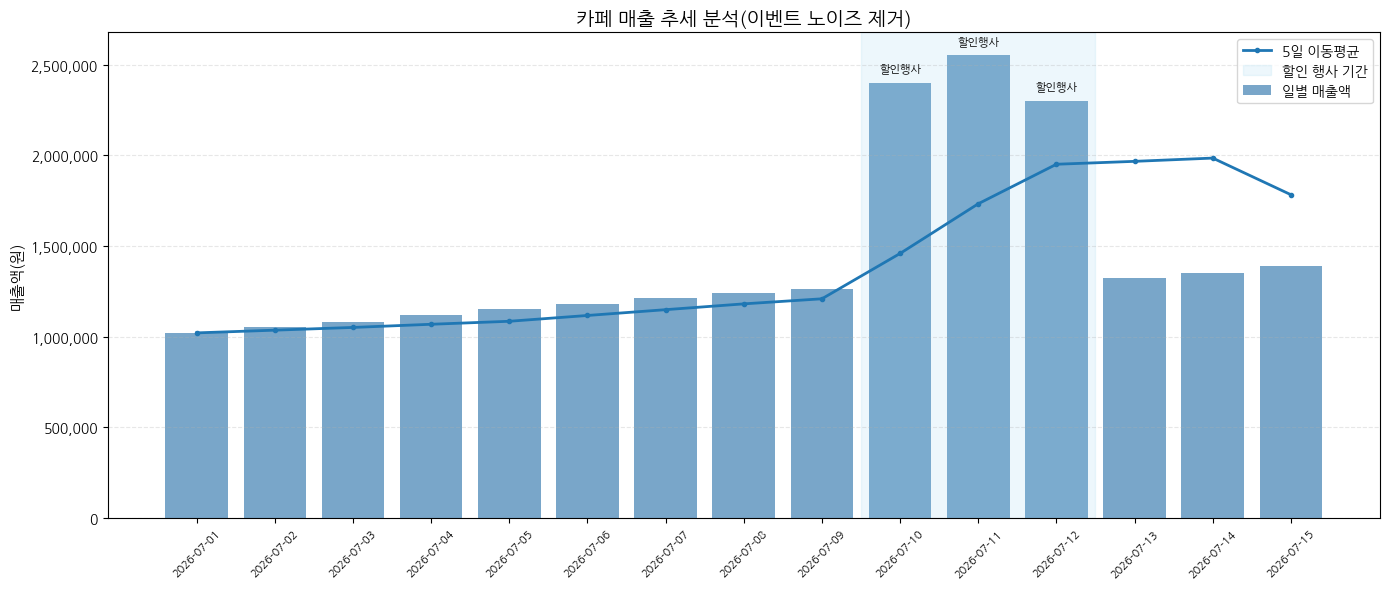


===== 이동평균 결과 =====
           날짜      매출액    5일 이동평균
0  2026-07-01  1020000  1020000.0
1  2026-07-02  1050000  1035000.0
2  2026-07-03  1080000  1050000.0
3  2026-07-04  1120000  1067500.0
4  2026-07-05  1150000  1084000.0
5  2026-07-06  1180000  1116000.0
6  2026-07-07  1210000  1148000.0
7  2026-07-08  1240000  1180000.0
8  2026-07-09  1260000  1208000.0
9  2026-07-10  2400000  1458000.0
10 2026-07-11  2550000  1732000.0
11 2026-07-12  2300000  1950000.0
12 2026-07-13  1320000  1966000.0
13 2026-07-14  1350000  1984000.0
14 2026-07-15  1390000  1782000.0


In [55]:
# ==========================================================
# 카페 매출 추세 분석(이벤트 노이즈 제거)
# Google Colab 업로드 버전
#
# 1열 : 날짜
# 2열 : 매출액(원)
# 3열 : 이벤트 여부
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from google.colab import files
import io

# ----------------------------------------------------------
# 한글 폰트
# ----------------------------------------------------------
!apt-get -qq install fonts-nanum > /dev/null

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ----------------------------------------------------------
# 파일 업로드
# ----------------------------------------------------------
print("엑셀 파일을 업로드하세요.")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[filename]))

# ----------------------------------------------------------
# 컬럼 설정
# ----------------------------------------------------------
df.columns = ['날짜', '매출액', '이벤트']

df['날짜'] = pd.to_datetime(df['날짜'])
df['매출액'] = pd.to_numeric(df['매출액'], errors='coerce')

# ----------------------------------------------------------
# 5일 이동평균
# ----------------------------------------------------------
df['5일 이동평균'] = (
    df['매출액']
    .rolling(window=5, min_periods=1)
    .mean()
)

# ----------------------------------------------------------
# 그래프
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14,6))

# 매출액 막대그래프
ax.bar(
    df['날짜'],
    df['매출액'],
    color='#4C89B8',
    alpha=0.75,
    width=0.8,
    label='일별 매출액'
)

# 이동평균 선그래프
ax.plot(
    df['날짜'],
    df['5일 이동평균'],
    color='#1F77B4',
    marker='o',
    linewidth=2,
    markersize=3,
    label='5일 이동평균'
)

# ----------------------------------------------------------
# 이벤트 기간(7/10~7/12)
# ----------------------------------------------------------
event_dates = pd.to_datetime([
    '2026-07-10',
    '2026-07-11',
    '2026-07-12'
])

# 이벤트 기간 음영
ax.axvspan(
    pd.Timestamp('2026-07-10') - pd.Timedelta(hours=12),
    pd.Timestamp('2026-07-12') + pd.Timedelta(hours=12),
    color='skyblue',
    alpha=0.15,
    label='할인 행사 기간'
)

# 이벤트 막대 위 텍스트
for event_day in event_dates:

    sales_value = df.loc[
        df['날짜'] == event_day,
        '매출액'
    ]

    if len(sales_value) > 0:

        ax.text(
            event_day,
            sales_value.iloc[0] + df['매출액'].max()*0.02,
            '할인행사',
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

# ----------------------------------------------------------
# x축 전체 날짜 표시
# ----------------------------------------------------------
all_dates = pd.date_range(
    '2026-07-01',
    '2026-07-15',
    freq='D'
)

ax.set_xticks(all_dates)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d')
)

plt.xticks(rotation=45, fontsize=8)

# ----------------------------------------------------------
# y축 천단위 표시
# ----------------------------------------------------------
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x):,}')
)

# ----------------------------------------------------------
# 제목 및 축
# ----------------------------------------------------------
ax.set_title(
    '카페 매출 추세 분석(이벤트 노이즈 제거)',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    '매출액(원)',
    fontsize=11
)

# ----------------------------------------------------------
# 범례
# ----------------------------------------------------------
ax.legend(
    loc='upper right'
)

# ----------------------------------------------------------
# 그리드
# ----------------------------------------------------------
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 이동평균 결과 출력
# ----------------------------------------------------------
print("\n===== 이동평균 결과 =====")
print(
    df[['날짜','매출액','5일 이동평균']]
)